# Phase 1: Can Vision Models See Hydraulic Features in a DEM?

**Goal:** Load a DEM, render it as a hillshade, and test whether Molmo/Florence-2 can identify channels, floodplains, ridges, and other hydraulic features.

**This is the single most important test.** If vision models can't recognize terrain features in a DEM visualization, the entire approach needs rethinking. If they can, even roughly, we have a viable path.

## Steps
1. Load a small, well-understood DEM
2. Render as hillshade, slope map, curvature map
3. Feed to vision models and ask for feature identification
4. Evaluate results against known features
5. If features are found, pass to SAM for precise segmentation
6. Visualize everything

In [9]:
# Stage 3: DEM Loading & Rendering

import rasterio
import numpy as np
from numpy import gradient
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from pathlib import Path
from PIL import Image

# Paths
DEM_PATH = Path("../data/input/1m elevation.tif")
OUTPUT_DIR = Path("../data/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3.1 Load DEM

In [10]:
# Load DEM and extract metadata
with rasterio.open(DEM_PATH) as src:
    elev = src.read(1)
    crs = src.crs
    transform = src.transform
    bounds = src.bounds
    nodata = src.nodata
    res = src.res

# Mask nodata pixels
elev_masked = np.where(elev == nodata, np.nan, elev)

# Extent for matplotlib (left, right, bottom, top)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

print(f"CRS: {crs}")
print(f"Resolution: {res[0]}m x {res[1]}m")
print(f"Shape: {elev.shape} ({elev.shape[1]}x{elev.shape[0]} pixels)")
print(f"Bounds: {bounds}")
print(f"Elevation range: {np.nanmin(elev_masked):.2f} – {np.nanmax(elev_masked):.2f} m")
print(f"NoData pixels: {np.isnan(elev_masked).sum()} ({100*np.isnan(elev_masked).sum()/elev_masked.size:.1f}%)")

CRS: EPSG:26914
Resolution: 1.0m x 1.0m
Shape: (3088, 5306) (5306x3088 pixels)
Bounds: BoundingBox(left=645114.9999575217, bottom=3982702.00003351, right=650420.9999575217, top=3985790.00003351)
Elevation range: 265.50 – 300.49 m
NoData pixels: 9397870 (57.4%)


## 3.2 Compute Terrain Derivatives (Hillshade, Slope, Curvature)

In [11]:
def compute_hillshade(elev, azimuth=315, altitude=45, cell_size=1.0):
    """Compute hillshade from elevation array.
    azimuth: sun direction in degrees (0=N, 90=E, 180=S, 270=W)
    altitude: sun angle above horizon in degrees
    """
    az_rad = np.radians(azimuth)
    alt_rad = np.radians(altitude)

    dy, dx = gradient(np.nan_to_num(elev, nan=0.0), cell_size)

    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(-dy, dx)

    hs = (np.cos(alt_rad) * np.cos(slope)
          + np.sin(alt_rad) * np.sin(slope) * np.cos(az_rad - aspect))

    hs = np.clip(hs, 0, 1)
    hs[np.isnan(elev)] = np.nan
    return hs


def compute_slope(elev, cell_size=1.0):
    """Compute slope in degrees from elevation array."""
    dy, dx = gradient(np.nan_to_num(elev, nan=0.0), cell_size)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)
    slope_deg[np.isnan(elev)] = np.nan
    return slope_deg


def compute_curvature(elev, cell_size=1.0):
    """Compute curvature (Laplacian of elevation surface)."""
    e = np.nan_to_num(elev, nan=0.0)
    dy = gradient(e, cell_size, axis=0)
    dx = gradient(e, cell_size, axis=1)
    dyy = gradient(dy, cell_size, axis=0)
    dxx = gradient(dx, cell_size, axis=1)

    curv = -(dxx + dyy)
    curv[np.isnan(elev)] = np.nan
    return curv


# Compute all derivatives
hillshade = compute_hillshade(elev_masked, azimuth=315, altitude=45, cell_size=res[0])
slope = compute_slope(elev_masked, cell_size=res[0])
curvature = compute_curvature(elev_masked, cell_size=res[0])

print(f"Hillshade range: {np.nanmin(hillshade):.3f} – {np.nanmax(hillshade):.3f}")
print(f"Slope range: {np.nanmin(slope):.2f} – {np.nanmax(slope):.2f} degrees")
print(f"Curvature range: {np.nanmin(curvature):.4f} – {np.nanmax(curvature):.4f}")

Hillshade range: 0.000 – 1.000
Slope range: 0.00 – 89.73 degrees
Curvature range: -1.7439 – 211.0122


## 3.3 Visualize All Renderings

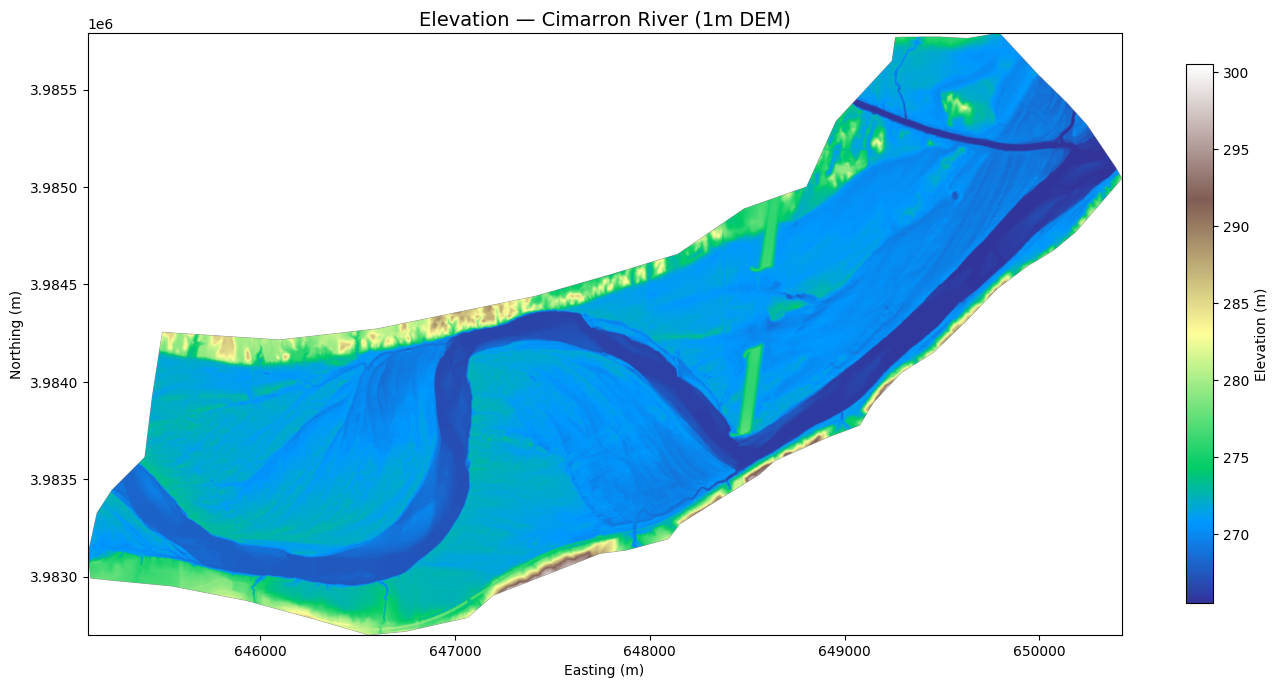

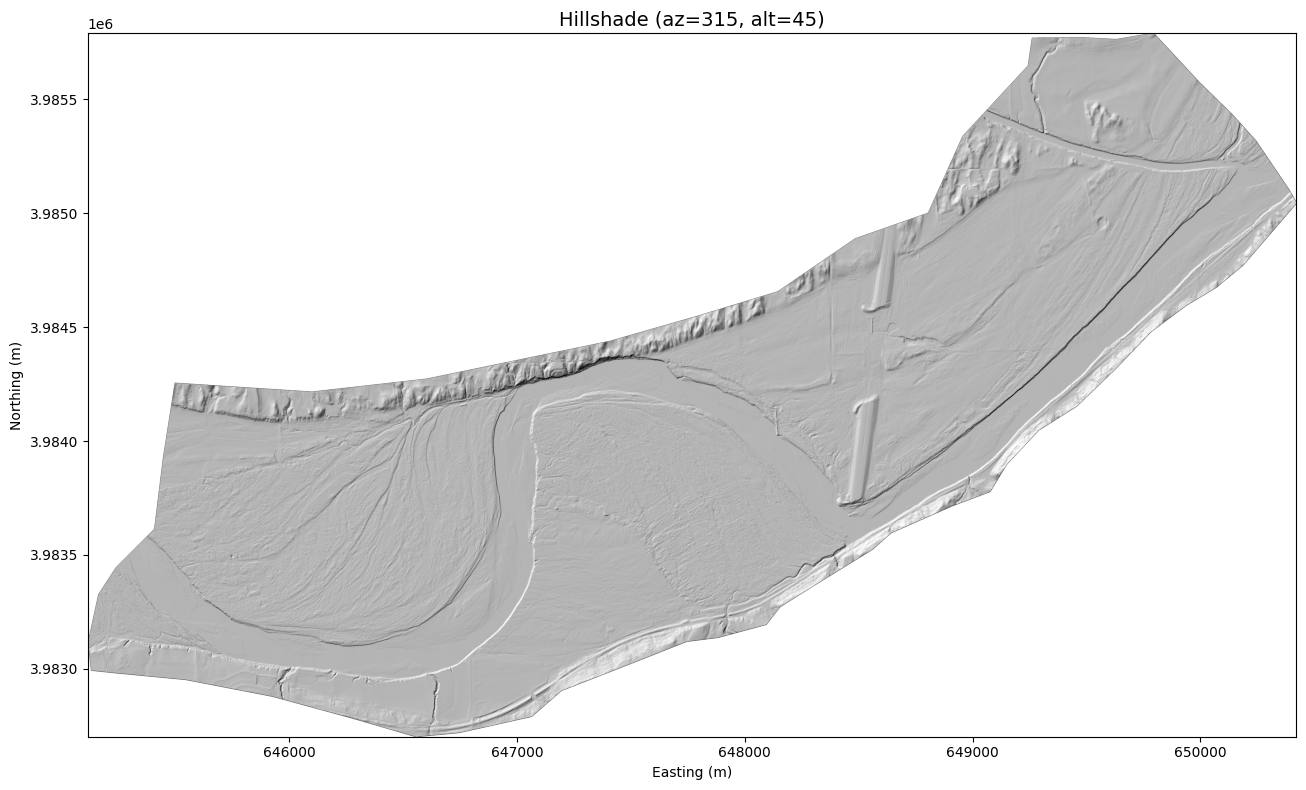

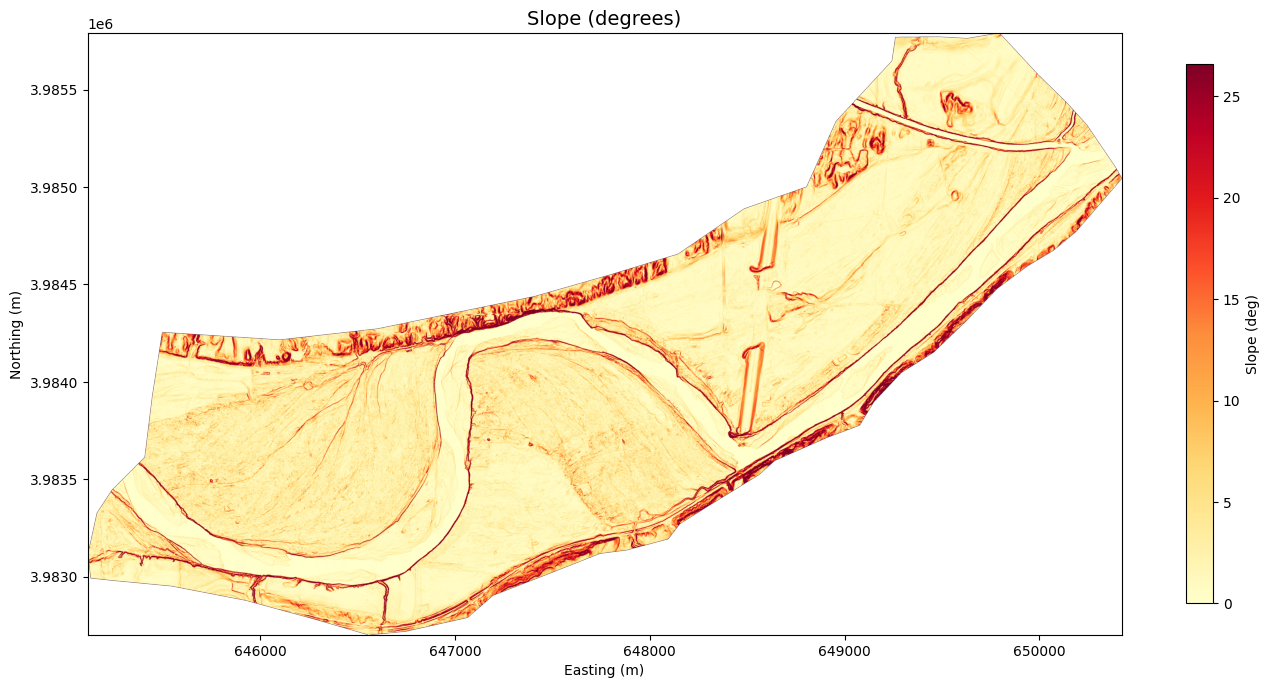

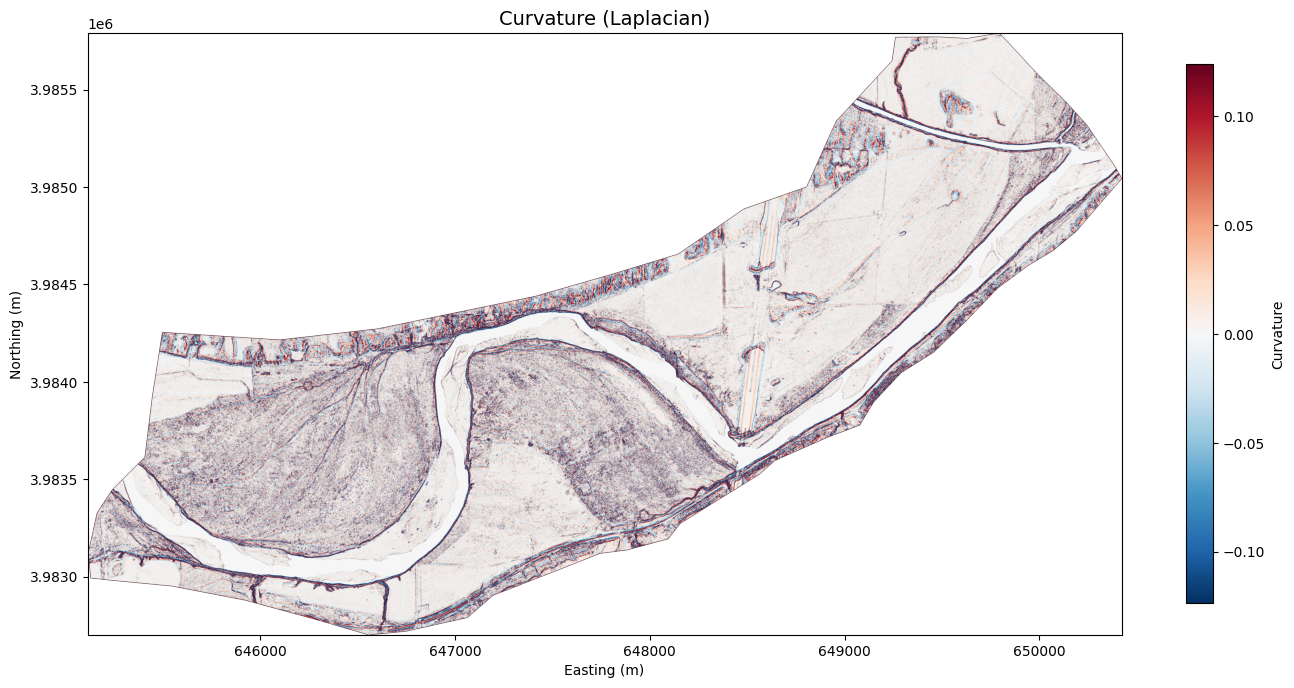

In [12]:
def plot_terrain(data, title, cmap="gray", extent=None, colorbar_label=None, vmin=None, vmax=None):
    """Plot a single terrain-derived map."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    im = ax.imshow(data, cmap=cmap, extent=extent, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    if colorbar_label:
        plt.colorbar(im, ax=ax, label=colorbar_label, shrink=0.7)
    plt.tight_layout()
    return fig

# --- Elevation ---
fig_elev = plot_terrain(elev_masked, "Elevation — Cimarron River (1m DEM)",
                        cmap="terrain", extent=extent, colorbar_label="Elevation (m)")
plt.show()

# --- Hillshade ---
fig_hs = plot_terrain(hillshade, "Hillshade (az=315, alt=45)",
                      cmap="gray", extent=extent)
plt.show()

# --- Slope ---
fig_slope = plot_terrain(slope, "Slope (degrees)",
                         cmap="YlOrRd", extent=extent, colorbar_label="Slope (deg)",
                         vmin=0, vmax=np.nanpercentile(slope, 98))
plt.show()

# --- Curvature ---
clim = np.nanpercentile(np.abs(curvature), 95)
fig_curv = plot_terrain(curvature, "Curvature (Laplacian)",
                        cmap="RdBu_r", extent=extent, colorbar_label="Curvature",
                        vmin=-clim, vmax=clim)
plt.show()

## 3.4 Export PNGs for Vision Model Input

These images will be fed directly to Molmo and Florence-2. We export clean images without axes, titles, or colorbars — just the raw terrain rendering on a white background (nodata = white).

In [13]:
def export_terrain_png(data, output_path, cmap="gray", vmin=None, vmax=None, bg_color=1.0):
    """Export terrain array as a clean PNG (no axes/labels) for vision model input.
    bg_color: value for nodata pixels (1.0 = white, 0.0 = black)
    """
    cm = plt.get_cmap(cmap)

    # Normalize data to 0-1
    if vmin is None:
        vmin = np.nanmin(data)
    if vmax is None:
        vmax = np.nanmax(data)
    normalized = (data - vmin) / (vmax - vmin)
    normalized = np.clip(normalized, 0, 1)

    # Apply colormap
    rgba = cm(normalized)

    # Set nodata pixels to background color
    mask = np.isnan(data)
    rgba[mask] = bg_color

    # Convert to 8-bit RGB
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    img = Image.fromarray(rgb)
    img.save(output_path)
    print(f"Saved: {output_path} ({img.size[0]}x{img.size[1]} px)")
    return img


# Export all renderings
img_hillshade = export_terrain_png(hillshade, OUTPUT_DIR / "cimarron_hillshade.png",
                                   cmap="gray")

img_slope = export_terrain_png(slope, OUTPUT_DIR / "cimarron_slope.png",
                               cmap="YlOrRd", vmin=0, vmax=np.nanpercentile(slope, 98))

img_curvature = export_terrain_png(curvature, OUTPUT_DIR / "cimarron_curvature.png",
                                   cmap="RdBu_r",
                                   vmin=-np.nanpercentile(np.abs(curvature), 95),
                                   vmax=np.nanpercentile(np.abs(curvature), 95))

img_elevation = export_terrain_png(elev_masked, OUTPUT_DIR / "cimarron_elevation.png",
                                   cmap="terrain")

print("\nAll terrain renders exported to data/output/")

Saved: ../data/output/cimarron_hillshade.png (5306x3088 px)
Saved: ../data/output/cimarron_slope.png (5306x3088 px)
Saved: ../data/output/cimarron_curvature.png (5306x3088 px)
Saved: ../data/output/cimarron_elevation.png (5306x3088 px)

All terrain renders exported to data/output/


# Stage 4: Vision Model Feature Detection — Gemma 4

**Core question:** Can a vision model identify hydraulic features (channels, floodplains, ridges, embankments) from DEM-derived images?

Using `google/gemma-4-26b-a4b-it` via OpenRouter (free tier). This is a qualitative test — we ask the model to describe what it sees and evaluate whether it correctly identifies terrain features.

## 4.1 Connect to Gemma 4 via OpenRouter

Using `google/gemma-4-26b-a4b-it` — a 26B parameter vision-language model via OpenRouter.

**Setup:** Add your `OPENROUTER_API_KEY` to `.env`. Get a key at https://openrouter.ai/keys

In [14]:
import os
import base64
import io
import time
from openai import OpenAI

# Load .env file if python-dotenv is available
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # Set OPENROUTER_API_KEY in your environment manually

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
if not OPENROUTER_API_KEY:
    raise ValueError(
        "Set OPENROUTER_API_KEY in your .env file or environment.\n"
        "Get a free key at: https://openrouter.ai/keys"
    )

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "google/gemma-4-26b-a4b-it"

# Verify connection
test = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say hello in one word."}],
    max_tokens=10,
)
print(f"OpenRouter connection OK: {test.choices[0].message.content}")
print(f"Model: {MODEL}")

OpenRouter connection OK: Hello.
Model: google/gemma-4-26b-a4b-it


## 4.2 Inference Utilities

Helper to encode images as base64 and query the vision model.

In [15]:
def resize_for_api(img, max_width=1024):
    """Resize image to reduce API token usage while preserving aspect ratio."""
    if img.width > max_width:
        ratio = max_width / img.width
        new_size = (max_width, int(img.height * ratio))
        return img.resize(new_size, Image.LANCZOS)
    return img


def image_to_base64(img):
    """Convert PIL Image to base64 data URL for the API."""
    img = resize_for_api(img)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"


def vision_query(image, prompt, max_tokens=1024):
    """Send an image + text prompt to the vision model and return the response."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_to_base64(image)}},
                ],
            }
        ],
        max_tokens=max_tokens,
    )
    return response.choices[0].message.content


# Store all results
vision_results = {}

print("Utilities ready.")

Utilities ready.


## 4.3 Hillshade — Feature Detection

The critical test: can the model identify hydraulic features from a hillshade rendering?  
We test with a general survey prompt, then targeted prompts for specific features.

In [16]:
# Load the hillshade image
img_hs = Image.open(OUTPUT_DIR / "cimarron_hillshade.png")

# --- Hillshade prompts ---
hillshade_prompts = {
    "general_survey": (
        "This is a hillshade rendering of a 1-meter resolution DEM (digital elevation model) "
        "of a river corridor. Identify all hydraulic and geomorphic features you can see. "
        "For each feature, describe its type, approximate location in the image, and shape. "
        "Look for: river channels, floodplains, terrace edges, ridges, point bars, oxbow lakes, "
        "levees, road embankments, or any other man-made structures."
    ),
    "channel": (
        "This is a hillshade of a river DEM. Describe the main river channel: "
        "Where is it in the image? How wide is it relative to the scene? "
        "Does it meander? Are there any secondary or abandoned channels visible?"
    ),
    "floodplain": (
        "This is a hillshade of a river DEM. Identify any flat floodplain areas. "
        "Where are they relative to the main channel? How extensive are they? "
        "Are there any subtle elevation changes within the floodplain?"
    ),
    "ridges_and_embankments": (
        "This is a hillshade of a river DEM. Are there any ridges, terrace edges, "
        "levees, or road embankments visible? Describe their locations and orientations. "
        "Do any linear features cross the floodplain?"
    ),
}

for key, prompt in hillshade_prompts.items():
    print(f"\n{'='*80}")
    print(f"TEST: hillshade_{key}")
    print(f"{'='*80}")

    response = vision_query(img_hs, prompt)
    vision_results[f"hillshade_{key}"] = {
        "prompt": prompt,
        "response": response,
        "rendering": "hillshade",
    }

    print(response)
    print()


TEST: hillshade_general_survey
Based on the hillshade rendering of this 1-meter resolution DEM, here is an identification of the visible hydraulic and geomorphic features:

### **Hydraulic and Geomorphic Features**

1.  **River Channel (Meander)**
    *   **Type:** Fluvial channel.
    *   **Location:** Centrally located, sweeping from the mid-left toward the upper-center of the image.
    *   **Shape:** A large, sinuous, S-shaped curve (meander) that defines the primary drainage path through the corridor.

2.  **Point Bar**
    *   **Type:** Fluvial depositional feature.
    *   **Location:** On the inner curve of the meander (the bottom-left/central area of the river bend).
    *   **Shape:** A broad, relatively smooth, gently sloping accumulation of sediment deposited on the inside of the bend where water velocity is lower.

3.  **Cut Bank / River Bank**
    *   **Type:** Fluvial erosional feature.
    *   **Location:** On the outer curve of the meander (the upper-center edge of th

## 4.4 Alternative Renderings — Slope, Curvature, Elevation

Test the same general survey prompt across different DEM renderings to determine which produces the best feature recognition.

In [17]:
survey_prompt = (
    "This is a {rendering_type} rendering of a 1-meter resolution DEM (digital elevation model) "
    "of a river corridor. Identify all hydraulic and geomorphic features you can see. "
    "For each feature, describe its type, approximate location in the image, and shape. "
    "Look for: river channels, floodplains, terrace edges, ridges, point bars, oxbow lakes, "
    "levees, road embankments, or any other man-made structures."
)

alt_renderings = {
    "slope": {
        "image_path": OUTPUT_DIR / "cimarron_slope.png",
        "description": "slope map (brighter = steeper)",
    },
    "curvature": {
        "image_path": OUTPUT_DIR / "cimarron_curvature.png",
        "description": "curvature map (red = convex, blue = concave)",
    },
    "elevation": {
        "image_path": OUTPUT_DIR / "cimarron_elevation.png",
        "description": "color-coded elevation map",
    },
}

for name, cfg in alt_renderings.items():
    print(f"\n{'='*80}")
    print(f"TEST: {name}_survey")
    print(f"{'='*80}")

    img = Image.open(cfg["image_path"])
    prompt = survey_prompt.format(rendering_type=cfg["description"])

    response = vision_query(img, prompt)
    vision_results[f"{name}_survey"] = {
        "prompt": prompt,
        "response": response,
        "rendering": name,
    }

    print(response)
    print()


TEST: slope_survey
Based on the provided slope map, which highlights steep areas in dark red/brown and flatter areas in light yellow, the following hydraulic and geomorphic features can be identified:

### **1. Fluvial (River) Features**
*   **River Channel:** 
    *   **Location:** The primary feature snaking through the center and bottom-left of the image.
    *   **Shape:** A sinuous, meandering line. The dark red color indicates steep banks/slopes immediately adjacent to the water level.
*   **Point Bar:**
    *   **Location:** On the inside of the large meander bend (the center-right area of the image).
    *   **Shape:** A broad, relatively flat, light-colored area (low slope) located on the convex side of the river bend, representing sediment deposition.
*   **Cut Bank / River Bank:**
    *   **Location:** Along the outer edge of the meander bends (e.g., the bottom-left curve and the curve moving toward the top-center).
    *   **Shape:** Indicated by the continuous, sharp, dar

## 4.5 Results Summary

How well did Gemma 4 identify hydraulic features across different renderings?

In [18]:
# Summary of all vision model results
print(f"{'Test':<35} {'Response Length':>15}  {'First 80 chars'}")
print("-" * 130)
for key, result in vision_results.items():
    resp_len = len(result["response"])
    preview = result["response"][:80].replace("\n", " ")
    print(f"{key:<35} {resp_len:>10} chars  {preview}...")

print(f"\nTotal queries: {len(vision_results)}")
print(f"Model: {MODEL}")
print(f"\n--- Review the full responses above to assess feature detection quality ---")

Test                                Response Length  First 80 chars
----------------------------------------------------------------------------------------------------------------------------------
hillshade_general_survey                  2684 chars  Based on the hillshade rendering of this 1-meter resolution DEM, here is an iden...
hillshade_channel                         1126 chars  Based on the provided hillshade of the Digital Elevation Model (DEM), here is a ...
hillshade_floodplain                      2117 chars  Based on the provided hillshade of the Digital Elevation Model (DEM), here is an...
hillshade_ridges_and_embankments          2235 chars  Based on the provided hillshade of the Digital Elevation Model (DEM), here is an...
slope_survey                              2595 chars  Based on the provided slope map, which highlights steep areas in dark red/brown ...
curvature_survey                          3107 chars  Based on the curvature map provided (where red indicates 